# Experiment 8:  OA strength testing for different gamma and beta values

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from Performance_measuring import test_dmp_performance

ModuleNotFoundError: No module named 'Performance_measuring'

In [ ]:

def spatial_coupling_OA(y, ydot, obstacles, gamma=1000.0, beta=6.0, eps=1e-9):

    #turn into 1D vectors
    y = np.asarray(y).reshape(-1,)
    ydot = np.asarray(ydot).reshape(-1,)

    
    d_dim = y.shape[0]
    Ct_total = np.zeros(d_dim) 

    vnorm = np.linalg.norm(ydot)
    if vnorm < eps:
        return Ct_total
 
    for o in obstacles:
        o = np.asarray(o).reshape(-1,)
        dvec = o - y
        dnorm = np.linalg.norm(dvec) 
        if dnorm < eps: 
            continue

        cosang = np.dot(dvec, ydot) / (dnorm * vnorm + eps)
        cosang = np.clip(cosang, -1.0, 1.0)
        psi = np.arccos(cosang)

        if d_dim == 2:
            cross_z = dvec[0]*ydot[1] - dvec[1]*ydot[0]
            sign = 1.0 if cross_z >= 0 else -1.0 
            Rydot = sign * np.array([-ydot[1], ydot[0]])

        elif d_dim == 3:
            r = np.cross(dvec, ydot)
            rnorm = np.linalg.norm(r)

            # FALLBACK 
            if rnorm < eps:  
                a = np.array([1.0, 0.0, 0.0])
                if abs(np.dot(a, ydot) / (np.linalg.norm(a)*vnorm + eps)) > 0.9:
                    a = np.array([0.0, 1.0, 0.0])
                r = np.cross(a, ydot)
                rnorm = np.linalg.norm(r)
                if rnorm < eps:
                    continue
            
            rhat = r / (rnorm + eps)

            Rydot = np.cross(rhat, ydot) + rhat * np.dot(rhat, ydot)

        else:
            raise ValueError("Only 2D or 3D supported.")

        Ct_total += gamma * Rydot * psi * np.exp(-beta * psi)
          
    return Ct_total


# DMP & OA

In [ ]:
def dmp_discrete_3d_OA(
    pos, dt,
    kp=150.0, kv=25.0, alpha=5.0, basis_num=40,
    speed=1.0,
    start_shift=None, goal_shift=None,
    init_vel_scale=1.0, init_vel_offset=None,
    obstacles=None, oa_gamma=1000.0, oa_beta=6.0
):

    pos = np.asarray(pos)
    assert pos.ndim == 2 and pos.shape[0] == 3, "pos must be shape (3, T)"
    assert speed > 0, "speed must be > 0"

    if obstacles is None:
        obstacles = []

    T = pos.shape[1]
    tau_demo = dt * T
    tau_new  = tau_demo / speed

    vel = np.gradient(pos, axis=-1) / dt
    acc = np.gradient(vel, axis=-1) / dt

    demo_start = pos[:, 0]
    demo_goal  = pos[:, -1]

    if start_shift is None:
        start_shift = np.zeros(3)
    if goal_shift is None:
        goal_shift = np.zeros(3)
    start_shift = np.asarray(start_shift).reshape(3,)
    goal_shift  = np.asarray(goal_shift).reshape(3,)

    newStart = demo_start + start_shift
    newGoal  = demo_goal  + goal_shift

    if init_vel_offset is None:
        init_vel_offset = np.zeros(3)
    init_vel_offset = np.asarray(init_vel_offset).reshape(3,)

    # -------------------------
    # Basis setup (UNCHANGED)
    # -------------------------
    u = np.zeros(basis_num)
    c = np.zeros(basis_num)
    h = np.zeros(basis_num)

    for i in range(basis_num):
        u[i] = (1.0 / basis_num) * i
        c[i] = np.exp(-alpha * u[i])

    for i in range(basis_num - 1):
        h[i] = 0.5 / ((0.65 * (c[i+1] - c[i]))**2)
    h[basis_num - 1] = h[basis_num - 2]

    # -------------------------
    # Learning (UNCHANGED)
    # -------------------------
    Phi = np.zeros(basis_num)
    Phi_total = np.zeros((T, basis_num))
    force = np.zeros((T, 3))

    s = 1.0
    for i in range(T):
        s = -alpha * s * dt / tau_demo + s

        addsum = 0.0
        for b in range(basis_num):
            Phi[b] = np.exp(-h[b] * (s - c[b])**2)
            addsum += Phi[b]

        # your framework: Phi includes *s
        Phi = Phi / addsum * s
        Phi_total[i, :] = Phi

        force[i, :] = (tau_demo*tau_demo)*acc[:, i] - kp*(demo_goal - pos[:, i]) + tau_demo*kv*vel[:, i]

    W = np.matmul(np.linalg.pinv(Phi_total), force)  # (basis_num, 3)


    T_new = int(np.round(tau_new / dt))
    T_new = max(T_new, 2)

    DMP_pos = np.zeros((3, T_new))
    DMP_vel = np.zeros((3, T_new))
    DMP_acc = np.zeros((3, T_new))

    DMP_pos[:, 0] = newStart
    DMP_vel[:, 0] = init_vel_scale * vel[:, 0] + init_vel_offset

    s = 1.0
    for i in range(T_new - 1):
        s = -alpha * s * dt / tau_new + s

        addsum = 0.0
        for b in range(basis_num):
            Phi[b] = np.exp(-h[b] * (s - c[b])**2)
            addsum += Phi[b]
    
        newForce = np.matmul(Phi / addsum, W) * s

        Ct = spatial_coupling_OA(DMP_pos[:, i], DMP_vel[:, i], obstacles, gamma=oa_gamma, beta=oa_beta)

        DMP_acc[:, i] = (kp*(newGoal - DMP_pos[:, i]) - tau_new*kv*DMP_vel[:, i] + newForce + Ct) / (tau_new**2)

        # integrate
        DMP_pos[:, i+1] = DMP_pos[:, i] + DMP_vel[:, i] * dt
        DMP_vel[:, i+1] = DMP_vel[:, i] + DMP_acc[:, i] * dt

    return DMP_pos, DMP_vel, DMP_acc, W, tau_new, newStart, newGoal


## Multi-View Plotting Helper

In [ ]:
def plot_dmp_views_points(pos, DMP_pos, objects, newGoal=None,
                          views=((20, 45), (20, 135), (60, 45), (10, -60))):
    objs = np.asarray(objects, dtype=float).reshape(-1, 3)

    # combine all points to compute a shared axis range
    P = np.column_stack([pos[0], pos[1], pos[2]])
    Q = np.column_stack([DMP_pos[0], DMP_pos[1], DMP_pos[2]])
    pts = np.vstack([P, Q, objs])

    if newGoal is not None:
        pts = np.vstack([pts, np.asarray(newGoal, dtype=float).reshape(1, 3)])

    mins = pts.min(axis=0)
    maxs = pts.max(axis=0)
    max_range = float(np.max(maxs-mins))
    min_val = float(np.min(mins))

    fig = plt.figure(figsize=(10, 10))
    for i, (elev, azim) in enumerate(views[:4], start=1):
        ax = fig.add_subplot(2, 2, i, projection="3d")

        ax.plot(pos[0], pos[1], pos[2], label="demo")
        ax.plot(DMP_pos[0], DMP_pos[1], DMP_pos[2], label="DMP")
        ax.scatter(objs[:, 0], objs[:, 1], objs[:, 2], marker='o', s=80, label="obstacle")

        if newGoal is not None:
            g = np.asarray(newGoal, dtype=float).reshape(3,)
            ax.scatter(g[0], g[1], g[2], marker='x', s=60, label="goal")
        else:
            ax.scatter(pos[0, -1], pos[1, -1], pos[2, -1], marker='x', s=60, label="goal")

        ax.set_xlim(min_val, min_val+max_range)
        ax.set_ylim(min_val, min_val+max_range)
        ax.set_zlim(min_val, min_val+max_range)

        ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
        ax.view_init(elev=elev, azim=azim)
        ax.legend()

    plt.tight_layout()
    plt.show()

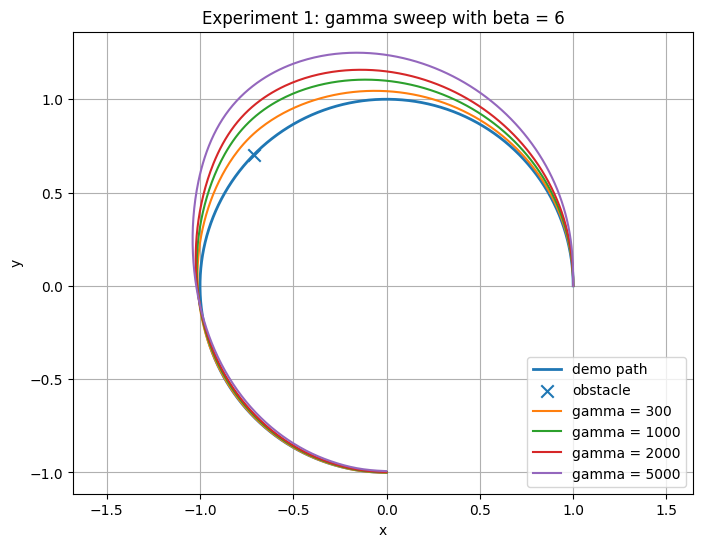

Experiment 1: beta = 6

gamma = 300
minimum obstacle distance:0.08260994858912893
final goal error:0.001652636099785578
RMS tracking error:0.04981988369006355

gamma = 1000
minimum obstacle distance:0.13949117734013763
final goal error:0.0007987161235044624
RMS tracking error:0.10029889656526672

gamma = 2000
minimum obstacle distance:0.18110026660036263
final goal error:0.00262133122927546
RMS tracking error:0.14566025068862057

gamma = 5000
minimum obstacle distance:0.2505440181767836
final goal error:0.00794980496486379
RMS tracking error:0.23310298776581762


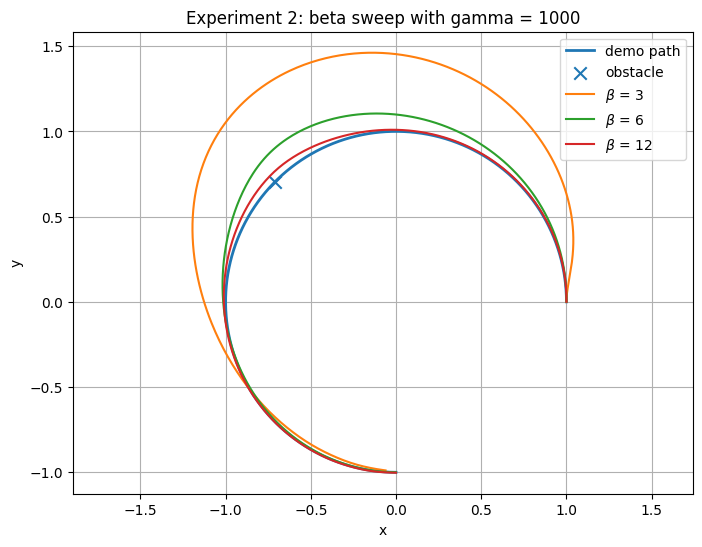


Experiment 2: Beta sweep (gamma = 1000)

beta = 3
  minimum obstacle distance: 0.4523337017793674
  final goal error:         0.06573424468294428
  RMS tracking error:       0.5218384032770836

beta = 6
  minimum obstacle distance: 0.13949117734013763
  final goal error:         0.0007987161235044624
  RMS tracking error:       0.10029889656526672

beta = 12
  minimum obstacle distance: 0.047005478107880576
  final goal error:         0.00253760351754911
  RMS tracking error:       0.023092872954596094


In [ ]:
def gen_3d_discrete_demo(dt=0.005, tau=2, Axy=1, z_amp=0.6):
    T = int(np.round(tau / dt)) # number of intervals
    t = np.linspace(0, tau, T)

    u = t / tau  # normalized time [0,1]

    # Finite "swirl" (not periodic) + z bump (0->peak->0)
    x = Axy * np.cos(1.5*np.pi*u)
    y = Axy * np.sin(1.5*np.pi*u)
    z = z_amp * np.sin(np.pi*u)

    pos = np.vstack([x, y, z])  # (3,T) 3 by number of intervals
    return pos, t

dt = 0.005
pos, t_demo = gen_3d_discrete_demo(dt=dt, tau=2, Axy=1, z_amp=0.6)

mid = pos.shape[1] // 2
obstacle = pos[:, mid]
obstacles = [obstacle]


gamma_values = [300, 1000, 2000, 5000]
beta_fixed = 6

gamma_results = []

plt.figure(figsize=(8, 6))
plt.plot(pos[0], pos[1], label="demo path", linewidth=2)
plt.scatter(obstacle[0], obstacle[1], marker="x", s=80, label="obstacle")

for gamma_val in gamma_values:
    DMP_pos, DMP_vel, DMP_acc, W, tau_new, newStart, newGoal = dmp_discrete_3d_OA(
        pos, dt,
        obstacles=obstacles,
        oa_gamma=gamma_val,
        oa_beta=beta_fixed
    )

    point_error, metrics = test_dmp_performance(
        pos, DMP_pos,
        obstacle_positions=obstacles
    )

    gamma_results.append((gamma_val, metrics))
    plt.plot(DMP_pos[0], DMP_pos[1], label=f"gamma = {gamma_val}")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Experiment 1: gamma sweep with beta = 6")
plt.legend()
plt.axis("equal")
plt.grid(True)
plt.show()

print("Experiment 1: beta = 6")
for gamma_val, metrics in gamma_results:
    print(f"\ngamma = {gamma_val}")
    print(f"minimum obstacle distance:{metrics['min_distance_overall']}")
    print(f"final goal error:{metrics['final_goal_error']}")
    print(f"RMS tracking error:{metrics['RMS_tracking_error']}")


beta_values = [3, 6, 12]
gamma_fixed = 1000

beta_results = []

plt.figure(figsize=(8, 6))
plt.plot(pos[0], pos[1], label="demo path", linewidth=2)
plt.scatter(obstacle[0], obstacle[1], marker="x", s=80, label="obstacle")

for beta_val in beta_values:
    DMP_pos, DMP_vel, DMP_acc, W, tau_new, newStart, newGoal = dmp_discrete_3d_OA(
        pos, 
        dt,
        obstacles=obstacles,
        oa_gamma=gamma_fixed,
        oa_beta=beta_val
    )

    point_error, metrics = test_dmp_performance(
        pos, DMP_pos,
        obstacle_positions=obstacles
    )

    beta_results.append((beta_val, metrics))
    plt.plot(DMP_pos[0], DMP_pos[1], label=f"$\\beta$ = {beta_val}")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Experiment 2: beta sweep with gamma = 1000")
plt.legend()
plt.axis("equal")
plt.grid(True)
plt.show()

print("\nExperiment 2: Beta sweep (gamma = 1000)")
for beta_val, metrics in beta_results:
    print(f"\nbeta = {beta_val}")
    print(f"minimum obstacle distance:{metrics['min_distance_overall']}")
    print(f"final goal error:{metrics['final_goal_error']}")
    print(f"RMS tracking error:{metrics['RMS_tracking_error']}")